## Analiss de Nomina Publica

*Importaciones*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_MISPAS = pd.read_excel('MISPAS.xlsx')
df_MAP = pd.read_excel('MAP.xlsx')
df_DGJP = pd.read_excel('DGJP.xlsx')
df_ONE = pd.read_excel('ONE.xlsx')
df_MINERD = pd.read_excel('MINERD.xlsx')


In [ ]:
df_DGJP

,NO,NOMBRE Y APELLIDO,CARGO,DEPARTAMENTO,CATEGORIA DEL SERVIDOR,GENERO,SALARIO,SEGURO DE VIDA,IMPUESTO SOBRE LA RENTA,AFP,SEGURO FAMILIAR DE SALUD SFS,SFS SALUD ADICIONAL,TOTAL DESCUENTOS,SUELDO NETO
0,1,JUAN ROSA,DIRECTOR GENERAL,DIRECCIÓN GENERAL,FIJO,MASCULINO,275000,25,53712.46,7892.50,6589.14,0.0,68219.10,206780.90
1,2,PEDRO PASCUAL JIMENEZ MARTE,ASISTENTE GENERAL,DIRECCION GENERAL,FIJO,MASCULINO,200000,25,35627.87,5740.00,6080.00,0.0,47472.87,152527.13
2,3,ELADIO ANTONIO PEGUERO MEJIA,ASISTENTE ESPECIAL,DIRECCION GENERAL,FIJO,MASCULINO,60000,25,3486.68,1722.00,1824.00,0.0,6940.70,53059.30
3,4,RAYDEL CASTILLO SOLIS,ASISTENTE,DIRECCION GENERAL,FIJO,MASCULINO,50000,25,1854.00,1435.00,1520.00,0.0,4834.00,45166.00
4,5,ROSA EMILIA VENTURA SANTANA,ASESOR,DIRECCION GENERAL,FIJO,FEMENINO,170500,25,28688.73,4893.35,5183.20,0.0,38790.28,131709.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,401,MAXUEL ESTERLIN COLON DUARTE,AUXILIAR,DEPARTAMENTO DE AUTOSEGURO-DGJP,STATUS SIMPLIFICADO,MASCULINO,40000,25,0.00,1148.00,1216.00,0.0,2389.00,37611.00
401,402,FELIPE ENMANUEL RAMIREZ CASTRO,ENCARGADO,DIVISION DE VALIDACION Y REGISTRO DE INSTRUMEN...,FIJO,MASCULINO,125000,25,17985.99,3587.50,3800.00,0.0,25398.49,99601.51
402,403,RAQUEL MELO D OLEO,COORDINADOR (A),DIVISION DE VALIDACION Y REGISTRO DE INSTRUMEN...,FIJO,FEMENINO,60000,25,3486.68,1722.00,1824.00,0.0,7057.68,52942.32
403,404,CARMEN DELIA JIMENEZ MARTE,ANALISTA,DIVISION DE VALIDACION Y REGISTRO DE INSTRUMEN...,CARRERA,FEMENINO,50000,25,1854.00,1435.00,1520.00,0.0,4834.00,45166.00


## **Armonizacion y concatencaion**

In [ ]:
def estandarizar_columnas(df, fuente):
    df = df.copy()

    if 'NOMBRE Y APELLIDO' in df.columns:
        df['Nombre'] = df['NOMBRE Y APELLIDO']
    elif 'Nombre' in df.columns and 'Apellido' in df.columns:
        df['Nombre'] = df['Nombre'] + ' ' + df['Apellido']

    renombrar = {
        'NO': 'No',
        'GENERO': 'Genero',
        'SALARIO': 'Sueldo',
        'SUELDO NETO': 'Ingreso Neto',
        'Sueldo Bruto': 'Sueldo',
        'Otros Desc.': 'Otros Descuentos',
        'Total Desc.': 'Total Descuentos',
        'Neto': 'Ingreso Neto',
    }
    df = df.rename(columns=renombrar)

    columnas_comunes = ['Nombre', 'Cargo', 'Departamento', 'Estatus', 'Genero',
                        'Sueldo', 'AFP', 'ISR', 'SFS', 'Otros Descuentos', 'Ingreso Neto']

    for col in columnas_comunes:
        if col not in df.columns:
            df[col] = None

    df = df[columnas_comunes]
    df['Fuente'] = fuente
    return df
df1 = estandarizar_columnas(df_MAP, "Administración Pública")
df2 = estandarizar_columnas(df_DGJP, "Pensionados")
df3 = estandarizar_columnas(df_MINERD, "Educación")
df4 = estandarizar_columnas(df_ONE, "Estadística")
df5 = estandarizar_columnas(df_MISPAS, "Salud Pública")


ELIMINA POSIBLES DUPLICADOS/NULOS QUE SE PUEDAD CAUSAR EN LA CONCATENACION

In [ ]:
def eliminar_columnas_duplicadas(df):
    return df.loc[:, ~df.columns.duplicated()]
df1 = eliminar_columnas_duplicadas(estandarizar_columnas(df_MAP, "Administración Pública"))
df2 = eliminar_columnas_duplicadas(estandarizar_columnas(df_DGJP, "Pensionados"))
df3 = eliminar_columnas_duplicadas(estandarizar_columnas(df_MINERD, "Educación"))
df4 = eliminar_columnas_duplicadas(estandarizar_columnas(df_ONE, "Estadística"))
df5 = eliminar_columnas_duplicadas(estandarizar_columnas(df_MISPAS, "Salud Pública"))
df_concatenado = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
generos_validos = ['FEMENINO', 'MASCULINO']
df_concatenado = df_concatenado[df_concatenado['Genero'].str.upper().isin(generos_validos)]
df_concatenado.to_excel("nominaconcatenada.xlsx", index=False)



/tmp/ipython-input-932747087.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_concatenado = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)


In [ ]:
df_concatenado.isnull().sum()

NameError: name 'df_concatenado' is not defined

In [ ]:
# Columnas de texto
columnas_texto = ['Nombre', 'Cargo', 'Departamento', 'Estatus', 'Genero']

# Columnas numéricas
columnas_numericas = ['Sueldo', 'AFP', 'ISR', 'SFS', 'Otros Descuentos', 'Ingreso Neto']

# Reemplazar nulos por "N/A" en texto
df_concatenado[columnas_texto] = df_concatenado[columnas_texto].fillna("N/A")

# Reemplazar nulos por 0 en columnas numéricas
df_concatenado[columnas_numericas] = df_concatenado[columnas_numericas].fillna(0)


In [ ]:
df_concatenado.isnull().sum()

,0
Nombre,0
Cargo,0
Departamento,0
Estatus,0
Genero,0
Sueldo,0
AFP,0
ISR,0
SFS,0
Otros Descuentos,0


In [ ]:
duplicados = df_concatenado.duplicated().sum()
print(f"\nFilas duplicadas: {duplicados}")



Filas duplicadas: 0


In [ ]:
df_concatenado.head(800)

,Nombre,Cargo,Departamento,Estatus,Genero,Sueldo,AFP,ISR,SFS,Otros Descuentos,Ingreso Neto,Fuente
297,JUAN ROSA,N/A,N/A,N/A,MASCULINO,275000.0,7892.50,0.0,0.0,0.0,206780.90,Pensionados
298,PEDRO PASCUAL JIMENEZ MARTE,N/A,N/A,N/A,MASCULINO,200000.0,5740.00,0.0,0.0,0.0,152527.13,Pensionados
299,ELADIO ANTONIO PEGUERO MEJIA,N/A,N/A,N/A,MASCULINO,60000.0,1722.00,0.0,0.0,0.0,53059.30,Pensionados
300,RAYDEL CASTILLO SOLIS,N/A,N/A,N/A,MASCULINO,50000.0,1435.00,0.0,0.0,0.0,45166.00,Pensionados
301,ROSA EMILIA VENTURA SANTANA,N/A,N/A,N/A,FEMENINO,170500.0,4893.35,0.0,0.0,0.0,131709.72,Pensionados
...,...,...,...,...,...,...,...,...,...,...,...,...
2244,LUIS MONTERO VALDEZ,VIGILANTE,DEPARTAMENTO DE SEGURIDAD Y VIGILANCIA- MSP,PERSONAL DE VIGILANCIA,MASCULINO,30000.0,0.00,0.0,0.0,1100.0,28900.00,Salud Pública
2245,LUIS ALFREDO MARTINEZ CABRERA,VIGILANTE,DEPARTAMENTO DE SEGURIDAD Y VIGILANCIA- MSP,PERSONAL DE VIGILANCIA,MASCULINO,15000.0,0.00,0.0,0.0,0.0,15000.00,Salud Pública
2246,LUIS ANTONIO PAULA GARCIA,VIGILANTE,DEPARTAMENTO DE SEGURIDAD Y VIGILANCIA- MSP,PERSONAL DE VIGILANCIA,MASCULINO,15000.0,0.00,0.0,0.0,6100.0,8900.00,Salud Pública
2247,LUIS DAVID PAULINO VALDEZ,VIGILANTE,DEPARTAMENTO DE SEGURIDAD Y VIGILANCIA- MSP,PERSONAL DE VIGILANCIA,MASCULINO,15000.0,0.00,0.0,0.0,0.0,15000.00,Salud Pública


In [ ]:
# Verifica el valor exacto
df_concatenado[df_concatenado['Sueldo'] > 1000000]

# Reemplazarlo manualmente con un valor realista
df_concatenado.loc[df_concatenado['Sueldo'] > 1000000, 'Sueldo'] = 154381.67



In [ ]:
df_concatenado[df_concatenado['Sueldo'] < 10000].sort_values('Sueldo')
df_concatenado.loc[df_concatenado['Sueldo'] < 10000, 'Sueldo'] = 15000  # o lo que estimes correcto


In [ ]:
resumen = df_concatenado.groupby("Fuente")['Sueldo'].agg(['count', 'mean', 'min', 'max', 'sum'])
resumen_redondeado = resumen.round(2)


In [ ]:
df_concatenado.groupby("Fuente")['Sueldo'].agg(['count', 'mean', 'min', 'max', 'sum'])
resumen_redondeado.style.format("{:,.2f}")


,count,mean,min,max,sum
Fuente,,,,,
Pensionados,404.00,"39,818.07","20,000.00","275,000.00","16,086,500.00"
Salud Pública,"5,374.00","35,480.58","10,000.00","330,000.00","190,672,644.85"


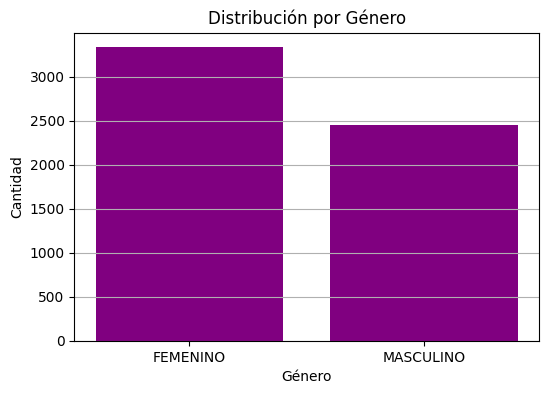

In [ ]:
genero = df_concatenado['Genero'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(genero.index, genero.values, color='purple')
plt.title('Distribución por Género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.grid(axis='y')
plt.show()


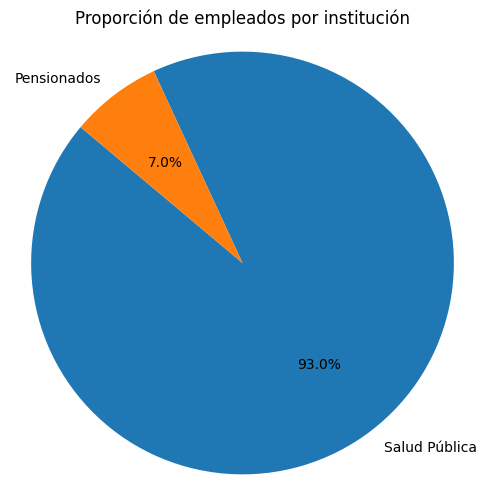

In [ ]:
empleados = df_concatenado['Fuente'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(empleados, labels=empleados.index, autopct='%1.1f%%', startangle=140)
plt.title('Proporción de empleados por institución')
plt.axis('equal')
plt.show()


In [ ]:
numericas = ['Sueldo', 'AFP', 'ISR', 'SFS', 'Otros Descuentos', 'Ingreso Neto']

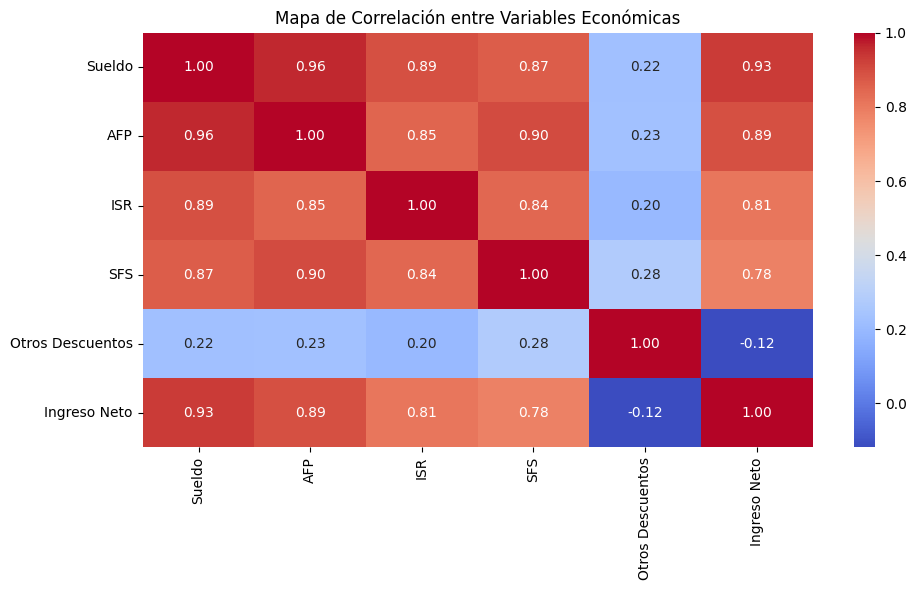

In [ ]:
# Mapa de correlacion entre variables economicas
plt.figure(figsize=(10, 6))
corr = df_concatenado[numericas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación entre Variables Económicas')
plt.tight_layout()
plt.show()

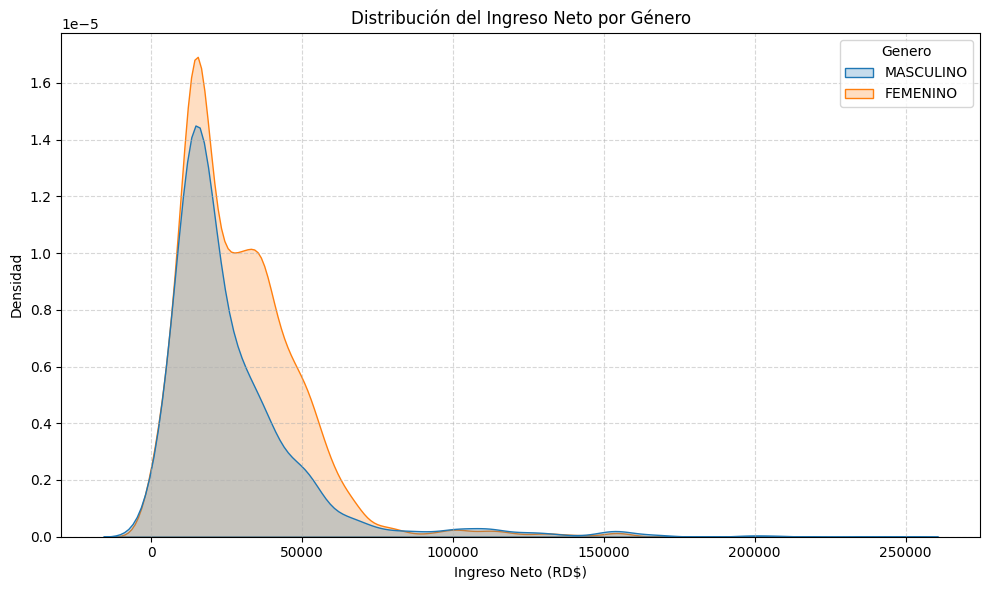

In [ ]:
# Distribución del Ingreso por Género
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_concatenado, x='Ingreso Neto', hue='Genero', fill=True)
plt.title('Distribución del Ingreso Neto por Género')
plt.xlabel('Ingreso Neto (RD$)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
print(df_concatenado.columns)

Index(['Nombre', 'Cargo', 'Departamento', 'Estatus', 'Genero', 'Sueldo', 'AFP',
       'ISR', 'SFS', 'Otros Descuentos', 'Ingreso Neto', 'Fuente'],
      dtype='object')
